In [7]:
from typing import Annotated, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage
import os

In [8]:
load_dotenv()

True

In [9]:
# llm = ChatOpenRouter(model='nvidia/nemotron-3-nano-30b-a3b:free')

llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     base_url="https://openrouter.ai/api/v1",
#     api_key=os.environ["OPENROUTER_API_KEY"],
#     model="deepseek/deepseek-chat-v3"
# )

In [10]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [12]:
def chat_node(state: ChatState):
    decision = interrupt({
        'type': 'approval',
        'reason': 'Model is about to answer a user question',
        'question': state['messages'][-1].content,
        'instruction': 'Approve this question? yes/no'
    })

    if decision['approved'] == 'no':
        return {'messages': [AIMessage(content="Not Approved.")]}
    else:
        response = llm.invoke(state['messages'])
        return {'messages': [response]}

In [13]:
## Building the Graph
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# checkpointer
checkpointer = MemorySaver()

# Compiler
chatbot_app = graph.compile(checkpointer=checkpointer)

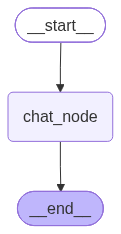

In [14]:
chatbot_app

In [31]:
## Thread id for the conversation
config = {
    'configurable':{
        'thread_id': 'thread-1'
    }
}

## Defining the Start state
start_state = {
    'messages':[
        ('user', 'Explain the UseEffect in the React in simple terms')
    ]
}

In [32]:
response = chatbot_app.invoke(start_state, config=config)

In [33]:
response

{'messages': [HumanMessage(content='Explain the UseEffect in the React in simple terms', additional_kwargs={}, response_metadata={}, id='86d573f0-e0ab-4280-817f-6b71e45db49d'),
  AIMessage(content='Not Approved.', additional_kwargs={}, response_metadata={}, id='875ee5b0-9870-479e-8684-38ca8d984799', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Explain the UseEffect in the React in simple terms', additional_kwargs={}, response_metadata={}, id='ad6f4992-85da-452b-b768-4903b9ba216f')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question', 'question': 'Explain the UseEffect in the React in simple terms', 'instruction': 'Approve this question? yes/no'}, id='7a9f585468008daf9e22d7e93188f2bf')]}

In [34]:
interrupt_msg = response['__interrupt__'][0].value

In [35]:
interrupt_msg

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'Explain the UseEffect in the React in simple terms',
 'instruction': 'Approve this question? yes/no'}

In [36]:
user_input = input(f'Backend Interruption message - {interrupt_msg} \n Approve this question ? (y/n): ')

In [37]:
final_res = chatbot_app.invoke(
    Command(resume={'approved': user_input}),
    config=config,
)

In [38]:
print(final_res)

{'messages': [HumanMessage(content='Explain the UseEffect in the React in simple terms', additional_kwargs={}, response_metadata={}, id='86d573f0-e0ab-4280-817f-6b71e45db49d'), AIMessage(content='Not Approved.', additional_kwargs={}, response_metadata={}, id='875ee5b0-9870-479e-8684-38ca8d984799', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Explain the UseEffect in the React in simple terms', additional_kwargs={}, response_metadata={}, id='ad6f4992-85da-452b-b768-4903b9ba216f'), AIMessage(content="**What\u202f`useEffect`\u202fdoes in React (in plain language)**  \n\nImagine you’re building a React component (a little “module” of UI). Most of the time you just tell React: “Here’s some JSX to render.” But sometimes you need to do something **after** the component shows up on the screen, or **when something changes**, or **when the component is about to disappear**.  \n\n`useEffect` is the hook that lets you run that “extra” code **after** React has painted the UI. It’s R

## Decision making can be done in the tool